## Monte Carlo Simulations for Credit Spreads

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import norm
import seaborn as sns

In [18]:
# -----------------------------
# Black-Scholes pricing function
# -----------------------------
def bs_call_price(S, K, T, r, sigma):
    if T <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# -----------------------------
# Credit spread simulation
# -----------------------------
def simulate_credit_spread(S0, K_short, K_long, T_days, sigma, r, credit, lot, paths=1000):
    dt = 1/252  # daily steps
    max_loss = (K_long - K_short - credit) * lot
    take_profit = credit * 0.5 * lot  # 50% profit
    stop_loss = max_loss * 0.5 # 50% of max loss

    pnl_list = []

    for _ in range(paths):
        S = S0
        pnl = 0
        for t in range(T_days):
            # simulate next step using GBM
            dW = np.random.normal(0, np.sqrt(dt))
            S = S * np.exp(-0.5*sigma**2*dt + sigma*dW)

            # remaining T in years
            T_remain = (T_days - t) / 252

            # option prices
            short_call = bs_call_price(S, K_short, T_remain, r, sigma)
            long_call = bs_call_price(S, K_long, T_remain, r, sigma)
            
            spread_val = (short_call - long_call) * lot
            pnl = credit * lot - spread_val

            # exit rules
            if pnl >= take_profit or pnl <= -stop_loss:
                break

        pnl_list.append(pnl)

    pnl_array = np.array(pnl_list)
    return {
        "mean_pnl": pnl_array.mean(),
        "std_pnl": pnl_array.std(),
        "win_rate": np.mean(pnl_array > 0),
        "max_loss": pnl_array.min(),
        "pnl_array": pnl_array
    }

# -----------------------------
# Parameters from your trade
# -----------------------------
S0 = 22713
K_short = 24000
K_long = 24200
T_days = 16  # trading days until expiry
sigma = 0.20  # assume 20% annualized IV
r = 0.06 # annual risk-free rate
credit = 39.95  # spread credit per lot
lot = 65

# -----------------------------
# Run simulation
# -----------------------------
results = simulate_credit_spread(S0, K_short, K_long, T_days, sigma, r, credit, lot, paths=10000)

print("Mean P&L:", round(results["mean_pnl"], 2))
print("Std P&L:", round(results["std_pnl"], 2))
print("Win rate:", round(results["win_rate"]*100, 2), "%")
print("Max loss:", round(results["max_loss"], 2))

Mean P&L: 888.1
Std P&L: 2353.25
Win rate: 90.15 %
Max loss: -10234.15


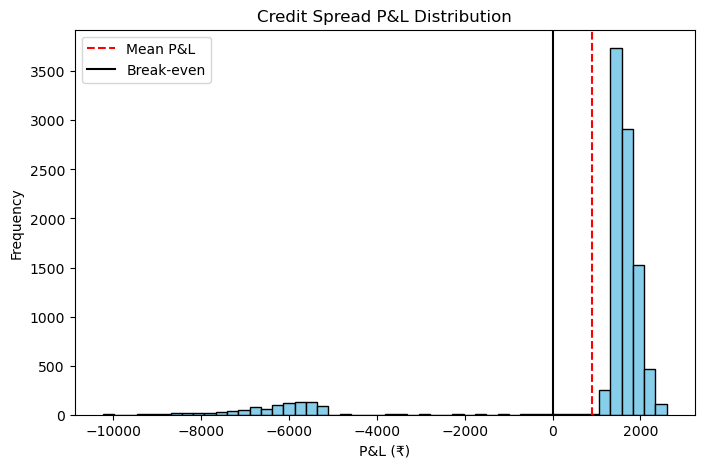

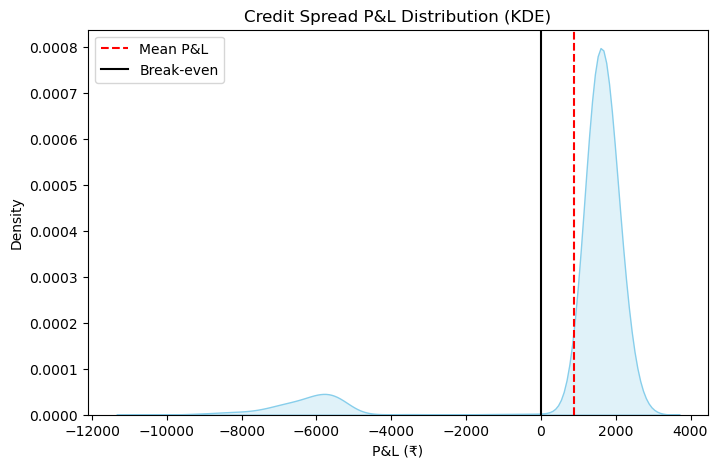

In [20]:
pnl_array = results["pnl_array"]

# Histogram
plt.figure(figsize=(8,5))
plt.hist(pnl_array, bins=50, color='skyblue', edgecolor='black')
plt.axvline(pnl_array.mean(), color='red', linestyle='--', label='Mean P&L')
plt.axvline(0, color='black', linestyle='-', label='Break-even')
plt.title("Credit Spread P&L Distribution")
plt.xlabel("P&L (₹)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# KDE
plt.figure(figsize=(8,5))
sns.kdeplot(pnl_array, fill=True, color='skyblue')
plt.axvline(pnl_array.mean(), color='red', linestyle='--', label='Mean P&L')
plt.axvline(0, color='black', linestyle='-', label='Break-even')
plt.title("Credit Spread P&L Distribution (KDE)")
plt.xlabel("P&L (₹)")
plt.ylabel("Density")
plt.legend()
plt.show()

In [39]:
# -----------------------------
# Black-Scholes pricing function
# -----------------------------
def bs_call_price(S, K, T, r, sigma):
    if T <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# -----------------------------
# Credit spread simulation
# -----------------------------
def simulate_credit_spread(S0, K_short, K_long, T_days, sigma, r, credit, lot, paths=1000):
    dt = 1/252  # daily steps
    max_loss = (K_long - K_short - credit) * lot
    take_profit = credit * 0.3 * lot  # 50% profit
    stop_loss = max_loss * 0.25 # 50% of max loss

    pnl_list = []

    for _ in range(paths):
        S = S0
        pnl = 0
        for t in range(T_days):
            # simulate next step using GBM
            dW = np.random.normal(0, np.sqrt(dt))
            S = S * np.exp(-0.5*sigma**2*dt + sigma*dW)

            # remaining T in years
            T_remain = (T_days - t) / 252

            # option prices
            short_call = bs_call_price(S, K_short, T_remain, r, sigma)
            long_call = bs_call_price(S, K_long, T_remain, r, sigma)
            
            spread_val = (short_call - long_call) * lot
            pnl = credit * lot - spread_val

            # exit rules
            if pnl >= take_profit or pnl <= -stop_loss:
                break

        pnl_list.append(pnl)

    pnl_array = np.array(pnl_list)
    return {
        "mean_pnl": pnl_array.mean(),
        "std_pnl": pnl_array.std(),
        "win_rate": np.mean(pnl_array > 0),
        "max_loss": pnl_array.min(),
        "pnl_array": pnl_array
    }

# -----------------------------
# Parameters from your trade
# -----------------------------
S0 = 22713
K_short = 24000
K_long = 24200
T_days = 16  # trading days until expiry
sigma = 0.20  # assume 20% annualized IV
r = 0.06 # annual risk-free rate
credit = 39.95  # spread credit per lot
lot = 65

# -----------------------------
# Run simulation
# -----------------------------
results = simulate_credit_spread(S0, K_short, K_long, T_days, sigma, r, credit, lot, paths=10000)

print("Mean P&L:", round(results["mean_pnl"], 2))
print("Std P&L:", round(results["std_pnl"], 2))
print("Win rate:", round(results["win_rate"]*100, 2), "%")
print("Max loss:", round(results["max_loss"], 2))

Mean P&L: 827.33
Std P&L: 1436.32
Win rate: 90.62 %
Max loss: -8215.58


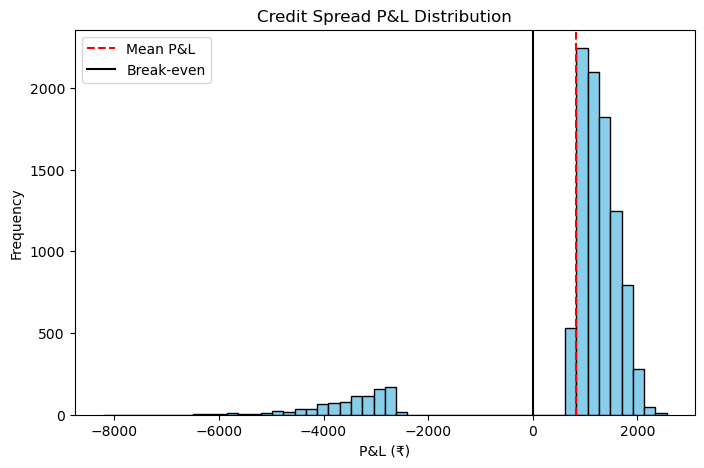

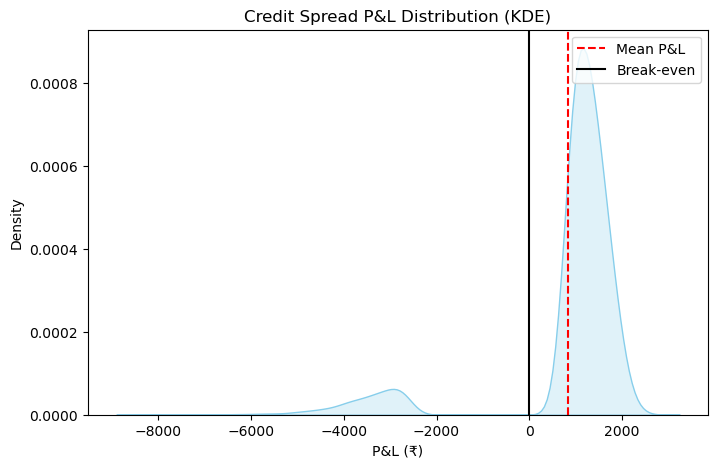

In [40]:
pnl_array = results["pnl_array"]

# Histogram
plt.figure(figsize=(8,5))
plt.hist(pnl_array, bins=50, color='skyblue', edgecolor='black')
plt.axvline(pnl_array.mean(), color='red', linestyle='--', label='Mean P&L')
plt.axvline(0, color='black', linestyle='-', label='Break-even')
plt.title("Credit Spread P&L Distribution")
plt.xlabel("P&L (₹)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# KDE
plt.figure(figsize=(8,5))
sns.kdeplot(pnl_array, fill=True, color='skyblue')
plt.axvline(pnl_array.mean(), color='red', linestyle='--', label='Mean P&L')
plt.axvline(0, color='black', linestyle='-', label='Break-even')
plt.title("Credit Spread P&L Distribution (KDE)")
plt.xlabel("P&L (₹)")
plt.ylabel("Density")
plt.legend()
plt.show()

## Realised vs Implied Vol Nifty50

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


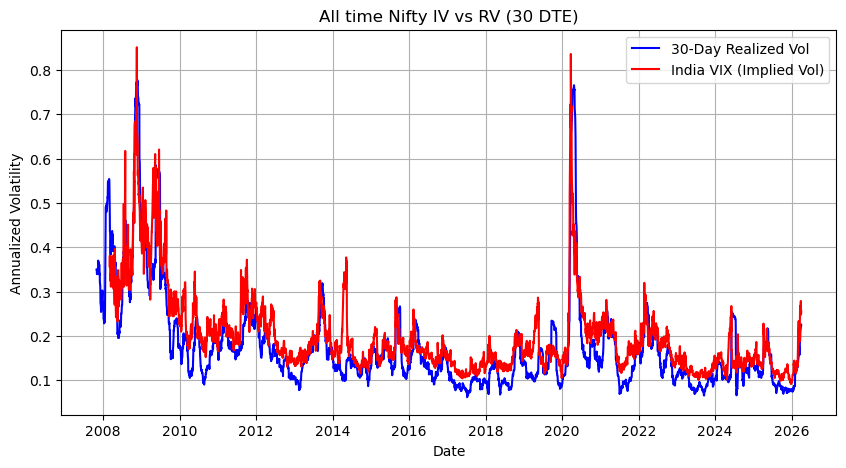

In [98]:
# import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

nifty = yf.download("^NSEI", start="2000-03-03")['Close']
returns = np.log(nifty / nifty.shift(1)).dropna()
# 30-day rolling realized vol
rv = returns.rolling(30).std() * np.sqrt(252)
vix = yf.download("^INDIAVIX", start="2000-03-03")['Close']
iv = vix / 100 
plt.figure(figsize=(10,5))
plt.plot(rv.index, rv, label='30-Day Realized Vol', color='blue')
plt.plot(iv.index, iv, label='India VIX (Implied Vol)', color='red')
plt.title("All time Nifty IV vs RV (30 DTE)")
plt.ylabel("Annualized Volatility")
plt.xlabel("Date")
plt.grid(True)
plt.legend()
plt.show();

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


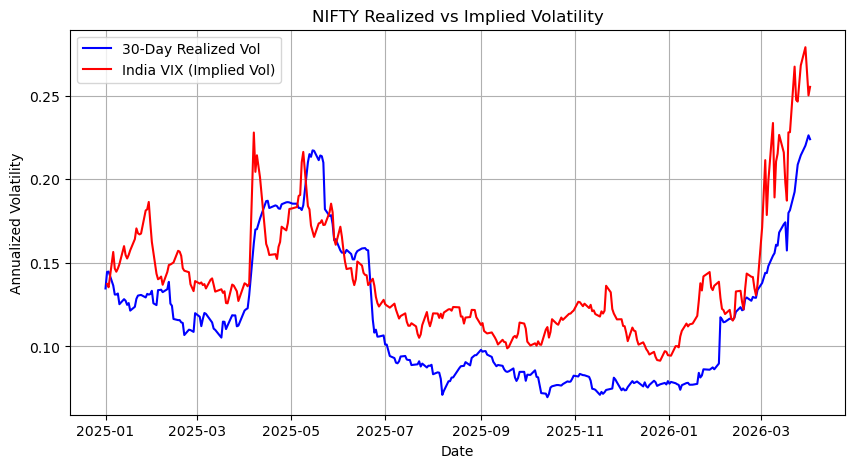

In [102]:
# import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

nifty = yf.download("^NSEI", start="2024-11-15")['Close']
returns = np.log(nifty / nifty.shift(1)).dropna()
# 30-day rolling realized vol
rv = returns.rolling(30).std() * np.sqrt(252)
vix = yf.download("^INDIAVIX", start="2025-01-01")['Close']
iv = vix / 100 
plt.figure(figsize=(10,5))
plt.plot(rv.index, rv, label='30-Day Realized Vol', color='blue')
plt.plot(iv.index, iv, label='India VIX (Implied Vol)', color='red')
plt.title("NIFTY Realized vs Implied Volatility")
plt.ylabel("Annualized Volatility")
plt.xlabel("Date")
plt.grid(True)
plt.legend()
plt.show();